# Chapter 09. 회귀 분석으로 숫자 예측하기

책 따라하면서 정리한 노트북. 이번 장 핵심은 점수를 높이는 게 아니라
**예측 시점 / 데이터 누수 / 시간 분할 / 베이스라인** 을 지키면서 정직하게 평가하는 것.

순서 (책에 나온 거 그대로 메모)
1. 예측 시점 정하기
2. 입력 변수 고르기 (누수 막기)
3. 시간 순서로 train/test 나누기
4. Pipeline 으로 전처리
5. train 안에서 TimeSeriesSplit 으로 후보 비교 → 모델 고정
6. 그 다음에야 Final Test (Dummy 랑 비교)

> 참고: `customers.csv` 가 주문 파일이랑 똑같은 내용이라 고객 정보/주문상세는
> `scripts/preprocess_data.py` 에서 seed 고정으로 가상 생성했음. 그래서 숫자 자체에 큰 의미는 없음.

## 0. 예측 문제 정리

- 예측 대상: 주문 한 건의 주문금액 합계 `order_total`
- 예측 시점: 주문 메타데이터랑 고객 정보는 알지만, 주문상세(수량/단가)는 모르는 시점
- 쓸 입력: `order_month`, `order_dayofweek`, `age`, `payment_method`, `gender`, `city`
- 뺄 것: `order_total`, `line_total`, `quantity`, `unit_price`, `item_count`, `total_quantity`, `avg_unit_price`, `order_status`, 각종 id

## 1. 프로젝트 경로 설정

In [1]:
import sys
from pathlib import Path

import pandas as pd

# notebooks/ch09 안에서 실행해도 프로젝트 루트를 찾도록 위로 올라가기
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

processed_dir = project_root / "data" / "processed"
report_dir = project_root / "reports"
figure_dir = report_dir / "figures"
report_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", project_root)
print("전처리 데이터:", processed_dir)

프로젝트 루트: C:\dev\llm-data-analysis-course
전처리 데이터: C:\dev\llm-data-analysis-course\data\processed


In [2]:
from src.regression import (
    CATEGORICAL_FEATURES,
    FEATURE_COLUMNS,
    FORBIDDEN_FEATURES,
    NUMERIC_FEATURES,
    TARGET_COLUMN,
    build_feature_audit,
    build_leakage_checklist,
    build_order_totals,
    build_regression_dataset,
    build_regression_validation,
    build_split_summary,
    create_diagnostic_figures,
    create_prediction_result,
    cross_validate_regression_models,
    load_regression_source_data,
    make_preprocessor,
    make_regression_models,
    public_prediction_result,
    save_regression_outputs,
    select_diagnostic_model,
    split_model_data_by_time,
    train_and_evaluate_models,
    validate_feature_columns,
)

## 2. 데이터 불러오기

In [3]:
datasets = load_regression_source_data(processed_dir)
customers = datasets["customers"]
orders = datasets["orders"]
order_items = datasets["order_items"]

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)

for name, df in datasets.items():
    print(name, df.columns.tolist())

customers: (126, 4)
orders: (300, 5)
order_items: (746, 5)
customers ['customer_id', 'gender', 'age', 'city']
orders ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
order_items ['order_id', 'product_id', 'quantity', 'unit_price', 'line_total']


## 3. 주문별 목표값 만들기

주문상세를 주문 단위로 합쳐서 `order_total` 을 만든다. 한 행 = 주문 한 건.

In [4]:
order_totals = build_order_totals(order_items)
display(order_totals.head())
print(order_totals.shape)

,order_id,order_total
0,1,25000
1,2,52000
2,3,233000
3,4,190000
4,5,3000


(300, 2)


직접 계산한 값이랑 함수 결과가 같은지 한 건만 확인해 봤음.

In [5]:
sample_order_id = order_totals.iloc[0]["order_id"]
sample_items = order_items[order_items["order_id"].eq(sample_order_id)]
manual_total = (sample_items["quantity"] * sample_items["unit_price"]).sum()
function_total = order_totals.loc[order_totals["order_id"].eq(sample_order_id), "order_total"].iloc[0]

print(manual_total, function_total, manual_total == function_total)

25000 25000 True


## 4. 주문 단위 모델링 데이터

In [6]:
model_data = build_regression_dataset(customers=customers, orders=orders, order_items=order_items)
display(model_data.head())
print(model_data.shape)

,order_id,customer_id,order_date,payment_method,order_status,order_total,gender,age,city,order_month,order_dayofweek
0,238,124,2025-07-09,bank_transfer,completed,92000,M,57,부산,7,2
1,79,62,2025-07-11,bank_transfer,refunded,267000,M,52,서울,7,4
2,12,98,2025-07-12,kakao_pay,completed,12000,F,51,대구,7,5
3,169,9,2025-07-12,kakao_pay,completed,41000,F,23,서울,7,5
4,152,62,2025-07-13,naver_pay,refunded,90000,M,52,서울,7,6


(300, 11)


In [7]:
print("행 수:", len(model_data))
print("고유 주문 수:", model_data["order_id"].nunique())
print("주문 ID 중복:", model_data["order_id"].duplicated().sum())
print("날짜 정렬됨:", model_data["order_date"].is_monotonic_increasing)

행 수: 300
고유 주문 수: 300
주문 ID 중복: 0
날짜 정렬됨: True


## 5. 입력 변수 / 누수 검사

숫자형 id 는 숫자처럼 보여도 크기 의미가 없어서 안 쓴다.
위험한 변수는 몰래 지우지 말고 **에러로 터지게** 하는 게 포인트.

In [8]:
print("숫자형:", NUMERIC_FEATURES)
print("범주형:", CATEGORICAL_FEATURES)
print("전체 입력:", FEATURE_COLUMNS)
print("목표값:", TARGET_COLUMN)

leaked_features = set(FEATURE_COLUMNS) & FORBIDDEN_FEATURES
print("누수 위험 입력:", leaked_features)
validate_feature_columns(FEATURE_COLUMNS)

숫자형: ['order_month', 'order_dayofweek', 'age']
범주형: ['payment_method', 'gender', 'city']
전체 입력: ['order_month', 'order_dayofweek', 'age', 'payment_method', 'gender', 'city']
목표값: order_total
누수 위험 입력: set()


일부러 나쁜 입력을 넣어서 에러가 나는지 확인.

In [9]:
bad_features = FEATURE_COLUMNS + ["order_total", "quantity"]

try:
    validate_feature_columns(bad_features)
except ValueError as error:
    print(error)

누수 위험 입력 변수가 있습니다: ['order_total', 'quantity']


In [10]:
feature_audit = build_feature_audit()
display(feature_audit)

feature_audit.to_csv(report_dir / "ch09_regression_feature_audit.csv", index=False, encoding="utf-8-sig")

,column,selected,role,reason
0,order_month,True,allowed_feature,"주문일에서 만든 값, 예측 시점에 알 수 있음"
1,order_dayofweek,True,allowed_feature,"주문일에서 만든 값, 예측 시점에 알 수 있음"
2,age,True,allowed_feature,고객 비식별 특성
3,payment_method,True,allowed_feature,주문 메타데이터
4,gender,True,allowed_feature,고객 비식별 특성
5,city,True,allowed_feature,고객 비식별 특성
6,avg_unit_price,False,forbidden,주문상세 집계 (목표값과 연결)
7,customer_id,False,forbidden,식별자
8,item_count,False,forbidden,주문상세 집계 (목표값과 연결)
9,line_total,False,forbidden,목표값 계산 재료


입력 변수 결측치는 행을 지우지 않고 Pipeline 의 Imputer 가 처리하게 둔다.

In [11]:
display(model_data[FEATURE_COLUMNS].isna().sum())

order_month        0
order_dayofweek    0
age                0
payment_method     0
gender             0
city               0
dtype: int64

## 6. 시간 순서 분할

주문은 시간 순서가 있으니까 무작위로 섞으면 안 된다 (미래가 train 에 들어갈 수 있음).
같은 날짜는 train/test 한쪽에만 들어가게 했다. 그래서 딱 80:20 은 안 나올 수 있음.

In [12]:
train_data, test_data = split_model_data_by_time(model_data, test_size=0.2)

split_summary = build_split_summary(train_data, test_data)
display(split_summary)

,split,rows,ratio_pct,start_date,end_date
0,train,242,80.7,2025-07-09,2026-04-08
1,test,58,19.3,2026-04-10,2026-07-08


In [13]:
train_max_date = train_data["order_date"].max()
test_min_date = test_data["order_date"].min()
print("train max:", train_max_date)
print("test min:", test_min_date)
print("train이 test보다 앞:", train_max_date.normalize() < test_min_date.normalize())

train_days = set(train_data["order_date"].dt.normalize())
test_days = set(test_data["order_date"].dt.normalize())
print("중복 날짜:", train_days & test_days)

split_summary.to_csv(report_dir / "ch09_regression_split_summary.csv", index=False, encoding="utf-8-sig")

train max: 2026-04-08 00:00:00
test min: 2026-04-10 00:00:00
train이 test보다 앞: True
중복 날짜: set()


In [14]:
X_train = train_data[FEATURE_COLUMNS].copy()
X_test = test_data[FEATURE_COLUMNS].copy()
y_train = train_data[TARGET_COLUMN].copy()
y_test = test_data[TARGET_COLUMN].copy()

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(X_train.columns.tolist() == X_test.columns.tolist())

(242, 6) (58, 6)
(242,) (58,)
True


이제부터 test(X_test, y_test)는 **봉인**. 후보 고를 때까지 안 건드린다.

## 7. 전처리 + 모델 Pipeline

- 숫자형: 중앙값으로 채우기 → StandardScaler
- 범주형: 최빈값으로 채우기 → OneHotEncoder(handle_unknown="ignore")

전처리를 Pipeline 안에 넣어야 각 train fold 에서만 fit 돼서 누수가 안 생김.

In [15]:
print(make_preprocessor())

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['order_month', 'order_dayofweek', 'age']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['payment_method', 'gender', 'city'])])


In [16]:
models = make_regression_models(random_state=42)
print(list(models.keys()))

for model_name, pipeline in models.items():
    print(model_name, list(pipeline.named_steps.keys()))

['Baseline Mean', 'Linear Regression', 'Random Forest']
Baseline Mean ['preprocessor', 'model']
Linear Regression ['preprocessor', 'model']
Random Forest ['preprocessor', 'model']


## 8. train 안에서 TimeSeriesSplit 으로 후보 비교

In [17]:
cv_summary = cross_validate_regression_models(
    models=models, X_train=X_train, y_train=y_train, max_splits=5
)
display(cv_summary.round(2))

cv_summary.to_csv(report_dir / "ch09_regression_cv_summary.csv", index=False, encoding="utf-8-sig")

,model,n_splits,cv_MAE_mean,cv_MAE_std,cv_R2_mean
0,Baseline Mean,5,95350.46,14097.40,-0.05
1,Linear Regression,5,115127.62,12535.45,-0.57
2,Random Forest,5,99490.62,11229.82,-0.22


CV 결과 읽는 법 (책 내용 정리)
- `cv_MAE_mean`: 훈련 기간 검증 구간의 평균 오차
- `cv_MAE_std`: 기간마다 오차가 얼마나 흔들리는지
- `cv_R2_mean`: 평균 예측 대비 설명력, 음수도 가능

In [18]:
selected_model_name = select_diagnostic_model(cv_summary)
print("선택 모델:", selected_model_name)

display(cv_summary[cv_summary["model"].eq(selected_model_name)].round(2))

선택 모델: Random Forest


,model,n_splits,cv_MAE_mean,cv_MAE_std,cv_R2_mean
2,Random Forest,5,99490.62,11229.82,-0.22


## 모델 선택 기록
- 선택 시점: Final Test 보기 전
- 비교 데이터: 훈련 기간 TimeSeriesSplit
- 선택 대상: Linear Regression, Random Forest (Baseline 은 선택 대상 아님)
- 선택 기준: 가장 낮은 cv_MAE_mean

여기서 선택한 모델은 테스트 결과가 안 좋아도 **바꾸지 않는다**.

## 9. Final Test (Baseline vs 고정 모델)

In [19]:
model_comparison, predictions = train_and_evaluate_models(
    models=models,
    selected_model_name=selected_model_name,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)
display(model_comparison.round(2))

,model,selection_role,train_MAE,test_MAE,test_RMSE,test_R2,MAE_improvement_vs_baseline_pct
0,Baseline Mean,baseline,95324.12,127790.68,156604.49,-0.00,0.00
1,Random Forest,selected_by_train_cv,74649.53,121476.77,160266.70,-0.05,4.94


In [20]:
selected_metrics = model_comparison[model_comparison["model"].eq(selected_model_name)].iloc[0]
train_test_gap = selected_metrics["test_MAE"] - selected_metrics["train_MAE"]
print("MAE gap (test - train):", round(train_test_gap))

model_comparison.to_csv(report_dir / "ch09_regression_model_comparison.csv", index=False, encoding="utf-8-sig")

MAE gap (test - train): 46827


In [21]:
base = model_comparison[model_comparison["model"].eq("Baseline Mean")].iloc[0]
print("Baseline test MAE:", round(base["test_MAE"]))
print("고정 모델 test MAE:", round(selected_metrics["test_MAE"]))
print("고정 모델 test RMSE:", round(selected_metrics["test_RMSE"]), "(Baseline", round(base["test_RMSE"]), ")")
print("고정 모델 test R2:", round(selected_metrics["test_R2"], 3))
print("MAE 개선율(%):", round(selected_metrics["MAE_improvement_vs_baseline_pct"], 2))

Baseline test MAE: 127791
고정 모델 test MAE: 121477
고정 모델 test RMSE: 160267 (Baseline 156604 )
고정 모델 test R2: -0.051
MAE 개선율(%): 4.94


### 결과 해석 (내가 이해한 대로)

- MAE 만 보면 Baseline 보다 조금 낮아졌지만, RMSE 는 오히려 Baseline 보다 높고 R² 도 0 보다 작다.
- 즉 평균으로 예측하는 것보다 확실히 낫다고 말하기 어렵다. 지표 하나만 보면 안 된다는 게 이런 거구나 싶음.
- 훈련 CV 에서는 Random Forest(99,490)도 Baseline(95,350)보다 MAE 가 높았음. 그러니까 Final Test 의 4.9% 개선은 우연일 수도 있어서 크게 믿기 어렵다.
- train MAE 가 test MAE 보다 꽤 낮아서 Random Forest 가 train 에 조금 과적합된 것 같다.
- 입력 변수(월, 요일, 나이, 결제수단, 성별, 지역)로는 주문금액 신호가 약하다. 데이터가 가상이라 당연한 결과일 수도 있음.
- 테스트 보고 모델 바꾸고 싶어도 **안 바꾼다**. 낮은 성능도 그대로 기록하는 게 이번 장 요점.

## 10. 자동 Validation

In [22]:
validation = build_regression_validation(
    train_data=train_data,
    test_data=test_data,
    cv_summary=cv_summary,
    selected_model_name=selected_model_name,
    model_comparison=model_comparison,
)
display(validation)
print("전부 통과:", validation["passed"].all())

validation.to_csv(report_dir / "ch09_regression_validation.csv", index=False, encoding="utf-8-sig")

,check,passed,detail
0,forbidden feature overlap = 0,True,[]
1,train max date < test min date,True,2026-04-08 < 2026-04-10
2,같은 날짜가 train/test에 없음,True,겹치는 날짜 0개
3,선택 모델이 CV 결과에 있음,True,Random Forest
4,선택 모델이 Baseline이 아님,True,Random Forest
5,Final Test에 Baseline 있음,True,
6,Final Test에 고정 모델 있음,True,
7,Final Test는 두 모델만 비교,True,"['Baseline Mean', 'Random Forest']"
8,R² 계산 가능한 테스트 크기,True,test rows = 58


전부 통과: True


## 11. 예측 오차 확인

In [23]:
selected_predictions = predictions[selected_model_name]
print(len(selected_predictions), len(y_test))

prediction_result = create_prediction_result(
    test_data=test_data,
    y_test=y_test,
    y_pred=selected_predictions,
    model_name=selected_model_name,
)
display(prediction_result.head(10).round(0))

58 58


,order_id,order_date,actual_order_total,predicted_order_total,residual,abs_error,model
0,84,2026-04-13,730000.0,95883.0,634117.0,634117.0,Random Forest
1,264,2026-07-05,519000.0,137115.0,381885.0,381885.0,Random Forest
2,128,2026-04-22,414000.0,90436.0,323564.0,323564.0,Random Forest
3,183,2026-05-23,373000.0,102738.0,270262.0,270262.0,Random Forest
4,73,2026-06-14,382000.0,156907.0,225093.0,225093.0,Random Forest
5,51,2026-06-15,303000.0,87351.0,215649.0,215649.0,Random Forest
6,259,2026-05-11,312000.0,102117.0,209883.0,209883.0,Random Forest
7,34,2026-06-30,288000.0,83051.0,204949.0,204949.0,Random Forest
8,76,2026-06-14,367000.0,163519.0,203481.0,203481.0,Random Forest
9,96,2026-05-11,292000.0,94043.0,197957.0,197957.0,Random Forest


공개용 결과에는 `order_id` 가 없어야 한다.

In [24]:
public_errors = public_prediction_result(prediction_result)
display(public_errors.head(5).round(0))
print("공개 결과에 order_id 있음?:", "order_id" in public_errors.columns)

,order_date,actual_order_total,predicted_order_total,residual,abs_error,model
0,2026-04-13,730000.0,95883.0,634117.0,634117.0,Random Forest
1,2026-07-05,519000.0,137115.0,381885.0,381885.0,Random Forest
2,2026-04-22,414000.0,90436.0,323564.0,323564.0,Random Forest
3,2026-05-23,373000.0,102738.0,270262.0,270262.0,Random Forest
4,2026-06-14,382000.0,156907.0,225093.0,225093.0,Random Forest


공개 결과에 order_id 있음?: False


In [25]:
direction = prediction_result["residual"].gt(0).map({True: "과소예측", False: "과대예측 또는 일치"})
display(direction.value_counts())

residual
과대예측 또는 일치    31
과소예측          27
Name: count, dtype: int64

절대오차가 큰 주문은 **원인이 확정된 게 아니라 점검해 볼 후보** 일 뿐이다.
(큰 주문금액인지, 특정 날짜인지, 데이터 문제인지는 이 데이터만으로 단정 못 함)

## 12. 진단 그래프

In [26]:
figure_paths = create_diagnostic_figures(prediction_result, figure_dir=figure_dir)

for name, figure_path in figure_paths.items():
    print(name, figure_path.exists(), figure_path.stat().st_size)

actual_vs_predicted True 35158
residual_histogram True 16236


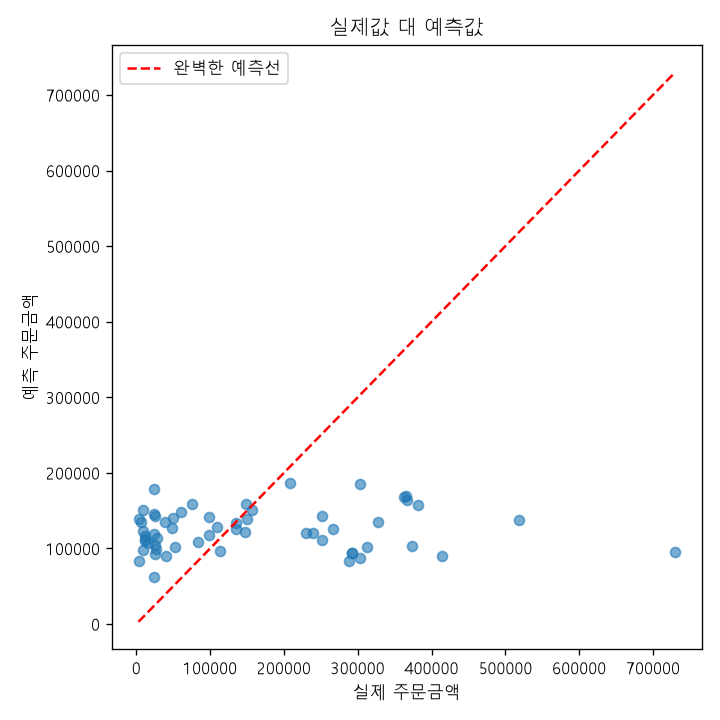

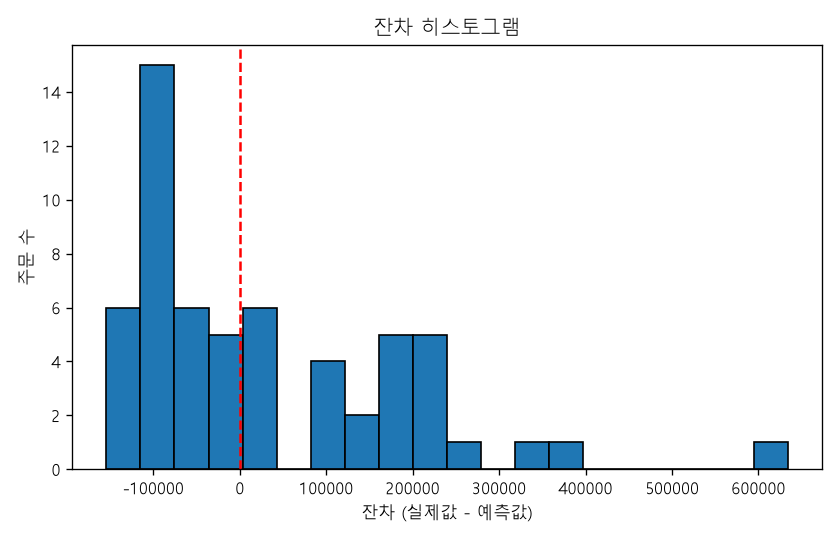

In [27]:
from IPython.display import Image, display

display(Image(filename=str(figure_paths["actual_vs_predicted"])))
display(Image(filename=str(figure_paths["residual_histogram"])))

- 실제값 대 예측값: 점들이 대각선 근처에 모이지 않고 예측값이 대부분 10만~20만 사이에 몰려 있음 → 모델이 금액 차이를 거의 구분 못 한다. 실제 금액이 큰 주문(30만 이상)은 예측이 한참 낮게 나옴.
- 잔차 히스토그램: 한쪽(오른쪽)으로 긴 꼬리가 있음. 실제값이 예측값보다 훨씬 큰 과소예측 주문이 있다는 뜻. 오른쪽 끝에 60만 넘는 잔차도 1건 있음 (점검 후보).

## 13. 결과 저장

In [28]:
checklist = build_leakage_checklist()
display(checklist)

output_paths = save_regression_outputs(
    model_data=model_data,
    train_data=train_data,
    test_data=test_data,
    split_summary=split_summary,
    feature_audit=feature_audit,
    cv_summary=cv_summary,
    selected_model_name=selected_model_name,
    model_comparison=model_comparison,
    prediction_result=prediction_result,
    validation=validation,
    checklist=checklist,
    report_dir=report_dir,
)
for key, path in output_paths.items():
    print(key, path.name, path.stat().st_size)

,item,question,checked
0,예측 시점,입력 변수가 예측 시점에 실제로 사용 가능한가?,True
1,목표 계산 재료,"quantity, unit_price, line_total 등이 입력에 없는가?",True
2,사후정보,order_status 같은 처리 후 정보가 입력에 없는가?,True
3,식별자,"order_id, customer_id, product_id가 입력에 없는가?",True
4,Pipeline 전처리,전처리가 Pipeline 안에서 train fold에만 fit되는가?,True
5,날짜 분리,같은 날짜가 train/test에 나뉘지 않았는가?,True
6,train CV 선택,모델 선택이 훈련 기간 TimeSeriesSplit에서 끝났는가?,True
7,test 최종 평가,test에서는 Baseline과 고정 모델만 비교했는가?,True
8,Dummy 비교,Dummy 베이스라인과 비교했는가?,True
9,지표 해석,"MAE, RMSE, R²를 함께 해석했는가?",True


split_summary ch09_regression_split_summary.csv 119
feature_audit ch09_regression_feature_audit.csv 1060
cv_summary ch09_regression_cv_summary.csv 282
model_comparison ch09_regression_model_comparison.csv 329
validation ch09_regression_validation.csv 519
checklist ch09_regression_checklist.csv 981
model_data_internal ch09_regression_model_data_internal.csv 18544
predictions_internal ch09_regression_predictions_internal.csv 5534
report ch09_regression_report.md 3097


In [29]:
internal_predictions = pd.read_csv(report_dir / "ch09_regression_predictions_internal.csv")
print("내부 order_id:", "order_id" in internal_predictions.columns)
print("공개 order_id:", "order_id" in public_prediction_result(internal_predictions).columns)

내부 order_id: True
공개 order_id: False


## 14. 이번 장 정리

1. 회귀는 목표값보다 **예측 시점** 부터 정한다.
2. 목표값 계산 재료(quantity, unit_price)도 누수다.
3. id 는 숫자여도 일반 변수로 쓰지 않는다.
4. 시간 데이터는 과거 → 미래로 분할하고, 같은 날짜는 한쪽에만 넣는다.
5. 전처리는 Pipeline 안에서 train 에만 fit.
6. 후보 비교는 train 안 TimeSeriesSplit, 선택 후 Final Test 는 한 번만.
7. Dummy 보다 실제로 나은지 꼭 확인. 낮은 성능/음수 R² 도 숨기지 않는다.
8. 내부 파일(order_id 포함)과 공개 결과를 분리한다.

다음은 Chapter 10 분류 분석.